# SensorGuard ML — EDA and Feature Engineering

This notebook contains exploratory data analysis for the SensorGuard ML project.

The goal is to understand the dataset before training a machine learning model.

## 1. Load data from SQLite

Data is loaded from the SQLite database created in Module 1.

In [10]:
import sys
sys.path.append("../src")

from preprocessing import load_data_from_sql, add_features

In [11]:
df = load_data_from_sql()
df_with_features = add_features(df)


## 2. Basic dataset overview

In this section, I check the basic structure of the dataset: shape, first rows, data types and descriptive statistics.

In [12]:
print("\n=== SHAPE ===\n")
print(df_with_features.shape)



=== SHAPE ===

(10000, 16)


In [13]:
print("\n=== HEAD ===\n")
df_with_features.head()


=== HEAD ===



,udi,product_id,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temperature_difference,power_proxy
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0


In [14]:
print("\n=== INFO ===\n")
df_with_features.info()


=== INFO ===

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   udi                     10000 non-null  int64  
 1   product_id              10000 non-null  str    
 2   product_type            10000 non-null  str    
 3   air_temperature_k       10000 non-null  float64
 4   process_temperature_k   10000 non-null  float64
 5   rotational_speed_rpm    10000 non-null  int64  
 6   torque_nm               10000 non-null  float64
 7   tool_wear_min           10000 non-null  int64  
 8   machine_failure         10000 non-null  int64  
 9   twf                     10000 non-null  int64  
 10  hdf                     10000 non-null  int64  
 11  pwf                     10000 non-null  int64  
 12  osf                     10000 non-null  int64  
 13  rnf                     10000 non-null  int64  
 14  temperature_difference  10000 non-n

In [15]:
print("\n=== DESCRIBE ===\n")
df_with_features.describe()


=== DESCRIBE ===



,udi,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temperature_difference,power_proxy
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,10.000630,59967.147040
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,1.001094,10193.093881
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.600000,10966.800000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,9.300000,53105.400000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,9.800000,59883.900000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,11.000000,66873.750000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,12.100000,99980.400000


After feature engineering, the dataset contains 10,000 rows and 16 columns.

Most columns are numerical. The text/categorical columns are `product_id` and `product_type`.

The `machine_failure` column is the target variable for binary classification.

## 3. Missing values and duplicates

Before training a machine learning model, I check whether the dataset contains missing values or duplicated rows.

In [32]:
print (df_with_features.isna().sum())

print (f"\n\nduplicates count = {df_with_features.duplicated().sum()}")

udi                       0
product_id                0
product_type              0
air_temperature_k         0
process_temperature_k     0
rotational_speed_rpm      0
torque_nm                 0
tool_wear_min             0
machine_failure           0
twf                       0
hdf                       0
pwf                       0
osf                       0
rnf                       0
temperature_difference    0
power_proxy               0
dtype: int64


duplicates count = 0


The dataset does not contain missing values or duplicated rows.

Therefore, at this stage I do not need to use `dropna()`, `fillna()` or remove duplicate records.

## 4. Target distribution

The target variable is `machine_failure`.

This is a binary classification problem:

- `0` — no machine failure
- `1` — machine failure

In this section, I check whether the target classes are balanced.

In [33]:
print("Target distribution — counts:")
print(df_with_features["machine_failure"].value_counts())

print("\nTarget distribution — percentage:")
print(df_with_features["machine_failure"].value_counts(normalize=True) * 100)

Target distribution — counts:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Target distribution — percentage:
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


The dataset is strongly imbalanced. Machine failures represent only 3.39% of all observations.

This means that accuracy alone can be misleading. A model could predict the majority class most of the time and still achieve high accuracy, while failing to detect real machine failures.

## 5. Feature comparison by target

In this section, I compare average feature values for normal cases and failure cases.

This helps to understand which features may be related to machine failure.

In [34]:
features_to_compare = [ 'air_temperature_k',
                        'process_temperature_k',
                        'temperature_difference',
                        'rotational_speed_rpm',
                        'torque_nm',
                        'tool_wear_min',
                        'power_proxy']

df_with_features.groupby("machine_failure")[features_to_compare].mean()

,air_temperature_k,process_temperature_k,temperature_difference,rotational_speed_rpm,torque_nm,tool_wear_min,power_proxy
machine_failure,,,,,,,
0,299.973999,309.995570,10.021571,1540.260014,39.629655,106.693717,59631.036446
1,300.886431,310.290265,9.403835,1496.486726,50.168142,143.781711,69545.803245


Failure cases tend to have higher average torque, higher tool wear and higher power proxy.

This suggests that machine load and tool wear may be important factors for predicting machine failure.

## 6. Basic plots

Basic plots help visually inspect class imbalance and feature distributions.

In this section, I create simple plots for the target variable and selected numerical features.

In [38]:
import matplotlib.pyplot as plt

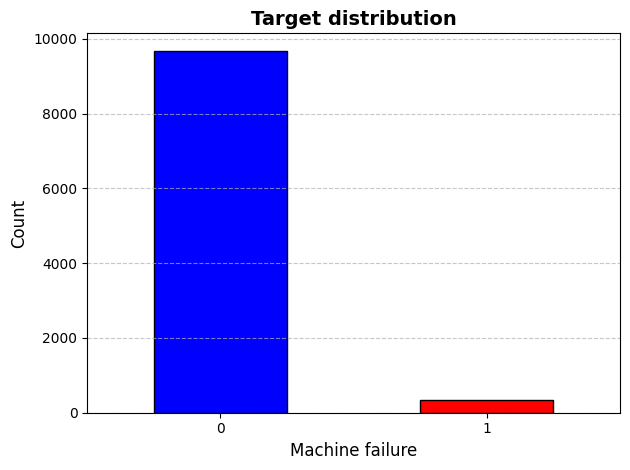

In [51]:
target_counts = df_with_features['machine_failure'].value_counts().sort_index()
target_counts.plot(kind = 'bar' , color = ["blue", "red"], edgecolor = "black")

plt.title("Target distribution", fontsize=14, fontweight="bold")
plt.xlabel("Machine failure", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation = 0)

plt.grid(axis='y', linestyle = "--", alpha = 0.7)

plt.tight_layout()

plt.show()

The plot confirms that the dataset is strongly imbalanced.  
Most observations belong to class `0`, while machine failure cases are rare.

### Torque distribution

This plot shows the distribution of torque values in the dataset.

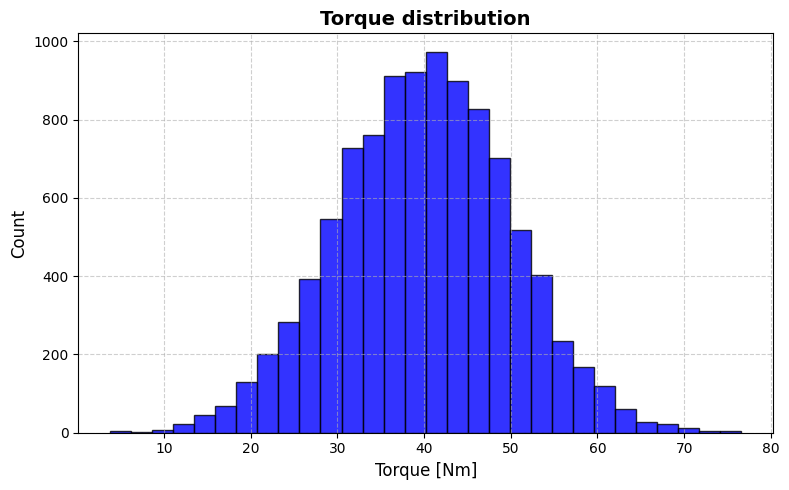

In [53]:
plt.figure(figsize=(8, 5))

df_with_features['torque_nm'].hist(bins=30, color = "blue", edgecolor = "black", alpha = 0.8)

plt.title("Torque distribution", fontsize=14, fontweight="bold")
plt.xlabel("Torque [Nm]", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The torque values are mostly concentrated around 40 Nm.  
Most observations are between approximately 30 and 50 Nm, while very low and very high torque values are less frequent.

### Tool wear distribution

This plot shows the distribution of tool wear values in the dataset.

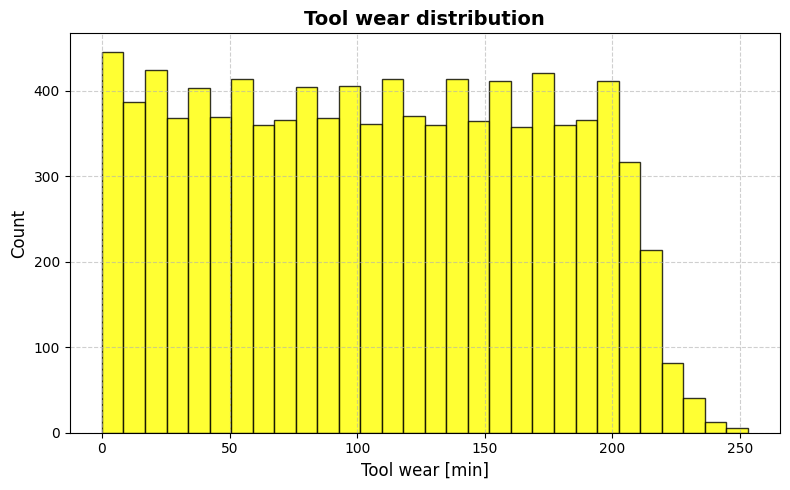

In [55]:
plt.figure(figsize=(8, 5))

df_with_features['tool_wear_min'].hist(bins=30, color = "yellow", edgecolor = "black", alpha = 0.8)

plt.title("Tool wear distribution", fontsize=14, fontweight="bold")
plt.xlabel("Tool wear [min]", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Tool wear values are distributed across a wide range.  
Most observations are between 0 and approximately 200 minutes, while very high tool wear values are less frequent.

### Power proxy distribution

This plot shows the distribution of the engineered `power_proxy` feature.

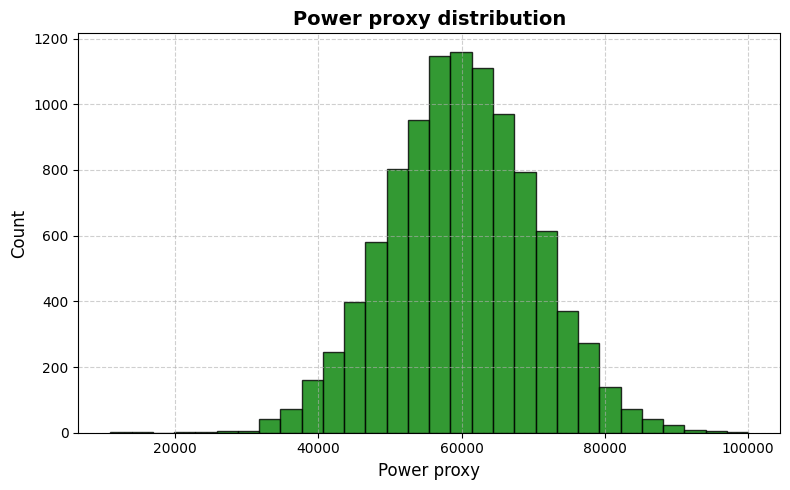

In [57]:
plt.figure(figsize=(8, 5))

df_with_features['power_proxy'].hist(bins=30, color = "green", edgecolor = "black", alpha = 0.8)

plt.title("Power proxy distribution", fontsize=14, fontweight="bold")
plt.xlabel("Power proxy", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The `power_proxy` feature is mostly concentrated around 60,000.  
Very low and very high values are less frequent.

This feature may be useful because it approximates machine load based on torque and rotational speed.

### Average torque by target

This plot compares the average torque value for normal cases and failure cases.

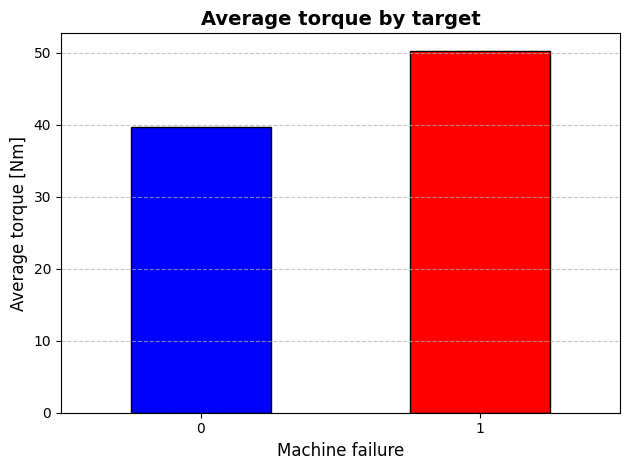

In [61]:
avg_torque = df_with_features.groupby('machine_failure')['torque_nm'].mean().sort_index()

avg_torque.plot(kind="bar", color=["blue", "red"], edgecolor="black")

plt.title("Average torque by target", fontsize=14, fontweight="bold")
plt.xlabel("Machine failure", fontsize=12)
plt.ylabel("Average torque [Nm]", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Failure cases have higher average torque than normal cases.  
This suggests that torque may be an important feature for predicting machine failure.

### Section 6 summary

The plots confirm the strong class imbalance in the dataset.

The target distribution plot shows that normal cases are much more frequent than failure cases.

The numerical feature distributions show that most values are concentrated around typical operating ranges, while extreme values are less frequent.

The average torque plot shows that failure cases have higher average torque than normal cases, which suggests that torque may be useful for predicting machine failure.

## 7. Conclusions

The exploratory data analysis showed that the dataset is clean and ready for the next machine learning step.

Main conclusions:

- The dataset contains 10,000 rows.
- After feature engineering, the dataset contains 16 columns.
- There are no missing values.
- There are no duplicated rows.
- The target variable is `machine_failure`.
- The dataset is strongly imbalanced:
  - `machine_failure = 0`: 96.61%
  - `machine_failure = 1`: 3.39%
- Because machine failures are rare, accuracy alone can be misleading.
- Failure cases tend to have higher average torque, higher tool wear and higher `power_proxy`.
- The engineered features `temperature_difference` and `power_proxy` may help the model better understand machine operating conditions.

In the next module, I will train baseline machine learning models and evaluate them using metrics such as precision, recall, F1-score and confusion matrix.

## Interview explanation

English:

> Before training a model, I loaded the data from SQLite into Pandas and performed exploratory data analysis. I checked data types, missing values, duplicated rows, descriptive statistics and target distribution. I found that the dataset is strongly imbalanced because machine failures represent only 3.39% of all observations, so accuracy alone may be misleading. I also created additional features such as `temperature_difference` and `power_proxy`.

Polish:

> Przed trenowaniem modelu wczytałem dane z SQLite do Pandas i przeprowadziłem eksploracyjną analizę danych. Sprawdziłem typy kolumn, brakujące wartości, duplikaty, statystyki opisowe oraz rozkład zmiennej docelowej. Zobaczyłem, że dane są mocno niezbalansowane, ponieważ awarie stanowią tylko 3,39% wszystkich obserwacji, dlatego sama accuracy może być myląca. Dodałem też nowe cechy, takie jak `temperature_difference` oraz `power_proxy`.
